# Evaluación FarSLIP vs RemoteCLIP sobre PASTIS-R real

Compara dos extractores de embeddings de teledetección sobre el **mismo subset real** de PASTIS-R:

- **FarSLIP** (Tang et al. 2024): CLIP afinado para viñedos y cultivos europeos mediante distilación desde Sentinel-2 y descripciones textuales.
- **RemoteCLIP** (Chen et al. 2024): CLIP afinado sobre 12 datasets de teledetección.

Si los pesos de RemoteCLIP no se pueden descargar desde Hugging Face, el extractor cae automáticamente a `openai/clip-vit-base-patch32` como respaldo (documentado en el log estructurado).

**Sin datos sintéticos**: el subset PASTIS-R se genera desde `data/PASTIS-R/metadata.geojson` y `DATA_S2/` reales con muestreo estratificado por clase. Si PASTIS-R no está en disco, el cuaderno lanza `FileNotFoundError` con instrucciones de `dvc pull` o de descarga manual desde Zenodo.

**Comparativa**: similitud coseno de los pares (FarSLIP, RemoteCLIP) por parcela y un clasificador lineal (LogisticRegression) sobre cada espacio de embeddings para medir separabilidad por clase.

In [1]:
PASTIS_SUBSET_PATH = "data/test_fixtures/pastis_eval_subset.parquet"
PASTIS_IMAGERY_PATH = "data/test_fixtures/pastis_eval_subset.parquet.imagery.parquet"
FARSLIP_EMBEDDINGS_PATH = "data/farslip/embeddings_italy.parquet"
REMOTECLIP_EMBEDDINGS_PATH = "data/farslip/remoteclip_embeddings_pastis.parquet"
FIGURES_SUBDIR = "us-023-preview/04_farslip_eval_pastis"
REPORTS_SUBDIR = "baseline/04_farslip_eval_pastis"
N_SAMPLES = 1024
RANDOM_STATE = 42
MLFLOW_EXPERIMENT = "baseline-04-farslip-vs-remoteclip"


In [2]:
from __future__ import annotations

import os
import sys
from pathlib import Path

# Bootstrap: locate the repo root by searching for pyproject.toml
_HERE = Path.cwd().resolve()
for _candidate in (_HERE, *_HERE.parents):
    if (_candidate / "pyproject.toml").is_file():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        break

from ml.utils.notebook_bootstrap import setup_notebook
from IPython.display import Markdown, display

env = setup_notebook(
    figures_subdir=FIGURES_SUBDIR,
    reports_subdir=REPORTS_SUBDIR,
)
display(Markdown(env.summary_markdown()))

# Chdir to the repo root so the relative paths from the `parameters` cell
# (FEATURES_PATH = "data/...", etc.) resolve the same regardless of where the
# kernel was launched (VS Code opens with cwd = the notebook folder).
# This preserves the papermill contract (parameters as relative strings) and
# eliminates FileNotFoundError caused by cwd != repo root.
os.chdir(env.repo)
display(Markdown(f"**cwd anclado al repo root**: `{env.repo}`"))


| Recurso | Estado |
|---|---|
| Repo root | `C:\Users\arthu\Proyectos\MNA\agro_sat_copilot` |
| Figures dir | `paper\figures\us-023-preview\04_farslip_eval_pastis` |
| Reports dir | `reports\baseline\04_farslip_eval_pastis` |
| Gemini API key | presente |
| Earth Engine | configurado |
| GEE project | `agrosat-copilot` |

**cwd anclado al repo root**: `C:\Users\arthu\Proyectos\MNA\agro_sat_copilot`

### Trazabilidad MLflow

Cada clasificador lineal (LogReg sobre FarSLIP, LogReg sobre RemoteCLIP) abre un run propio en el experimento `baseline-04-farslip-vs-remoteclip`. La métrica principal del run es el F1-macro promedio del 5-fold estratificado sobre el espacio de embeddings correspondiente — cuanto mayor, mejor separa el espacio las clases PASTIS.

In [3]:
from ml.utils.mlflow_utils import (
    resolve_tracking_uri,
    track_experiment,
    server_is_reachable,
)

# Robust tracking URI resolution: if MLFLOW_TRACKING_URI is set in
# `.env.local` but the server is unreachable (Docker off, container
# stopped), fall back to `file:./mlruns` so the notebook does not stop.
_candidate_uri = resolve_tracking_uri(None, probe_server=False)
if _candidate_uri.startswith(('http://', 'https://')) and not server_is_reachable(_candidate_uri):
    mlflow_uri = 'file:./mlruns'
    display(Markdown(
        f'> Servidor MLflow `{_candidate_uri}` no responde. '
        'Caigo a tracking local `file:./mlruns`. '
        'Para registrar en el server, ejecuta `docker compose up -d mlflow` '
        'antes de re-ejecutar las celdas MLflow.'
    ))
else:
    mlflow_uri = _candidate_uri
display(Markdown(
    f'**MLflow tracking URI**: `{mlflow_uri}` · '
    f'**Experimento**: `{MLFLOW_EXPERIMENT}`'
))
MLFLOW_RUN_IDS: dict[str, str] = {}


**MLflow tracking URI**: `http://localhost:5010` · **Experimento**: `baseline-04-farslip-vs-remoteclip`

## 1. Materialización del subset PASTIS real (si no existe)

In [4]:
import polars as pl
from pathlib import Path
from ml.utils.baseline_notebook_helpers import (
    materialize_pastis_eval_subset_if_missing,
    materialize_remoteclip_if_missing,
)

subset_path = materialize_pastis_eval_subset_if_missing(
    output_path=PASTIS_SUBSET_PATH,
    n_samples=N_SAMPLES,
)
subset = pl.read_parquet(subset_path)
display(Markdown(f'**Subset PASTIS-R real**: `{subset.height}` parcelas en `{subset_path}`'))
display(subset.head(8))
display(Markdown('**Distribución de clases en el subset**:'))
display(
    subset.group_by('class_id', 'class_name').len()
    .sort('len', descending=True)
)


2026-05-28 01:48:13 [info     ] pastis_eval_subset_cache_hit   path=data\test_fixtures\pastis_eval_subset.parquet


**Subset PASTIS-R real**: `1024` parcelas en `data\test_fixtures\pastis_eval_subset.parquet`

parcel_id,patch_id,instance_id,class_id,class_name,tile,fold,lon,lat,n_pixels
str,i64,i64,i64,str,str,i64,f64,f64,i64
"""10006_4""",10006,4,1,"""Meadow""","""t30uxv""",3,-1.557374,49.218979,602
"""10036_22""",10036,22,1,"""Meadow""","""t30uxv""",4,-0.447523,48.923396,294
"""10062_60""",10062,60,1,"""Meadow""","""t30uxv""",4,-1.49753,48.87277,232
"""10076_16""",10076,16,1,"""Meadow""","""t30uxv""",3,-0.464321,49.280756,27
"""10079_27""",10079,27,1,"""Meadow""","""t30uxv""",1,-0.705709,49.009434,162
"""10079_37""",10079,37,1,"""Meadow""","""t30uxv""",1,-0.705709,49.009434,101
"""10091_43""",10091,43,1,"""Meadow""","""t30uxv""",5,-0.317735,48.736186,51
"""10091_47""",10091,47,1,"""Meadow""","""t30uxv""",5,-0.317735,48.736186,270


**Distribución de clases en el subset**:

class_id,class_name,len
i64,str,u32
1,"""Meadow""",222
8,"""Grapevine""",100
3,"""Corn""",94
2,"""Soft winter wheat""",71
16,"""Orchard""",47
14,"""Leguminous fodder""",46
5,"""Winter rapeseed""",46
12,"""Fruits, vegetables, flowers""",45
4,"""Winter barley""",40


## Extracción de embeddings RemoteCLIP (si no existen)

In [5]:
remoteclip_path = materialize_remoteclip_if_missing(
    pastis_eval_subset_path=PASTIS_SUBSET_PATH,
    imagery_path=PASTIS_IMAGERY_PATH,
    output_path=REMOTECLIP_EMBEDDINGS_PATH,
)
remoteclip = pl.read_parquet(remoteclip_path)
display(Markdown(f'**RemoteCLIP**: `{remoteclip.shape}` (cols con prefijo `remoteclip_`)'))
display(remoteclip.select(['parcel_id', 'year', 'remoteclip_000', 'remoteclip_001']).head(5))


2026-05-28 01:48:13 [info     ] remoteclip_cache_hit           path=data\farslip\remoteclip_embeddings_pastis.parquet


**RemoteCLIP**: `(48641, 514)` (cols con prefijo `remoteclip_`)

parcel_id,year,remoteclip_000,remoteclip_001
str,i16,f32,f32
"""10006_4""",2019,-0.013127,-0.022996
"""10006_4""",2019,-0.013127,-0.022996
"""10006_4""",2019,-0.013127,-0.022996
"""10006_4""",2019,-0.013127,-0.022996
"""10006_4""",2019,-0.013127,-0.022996


## Carga de los embeddings FarSLIP (ruta canónica)

In [6]:
farslip_path = Path(FARSLIP_EMBEDDINGS_PATH)
if not farslip_path.exists():
    raise FileNotFoundError(
        f'FarSLIP no encontrado en {farslip_path}. Ejecuta '
        '`dvc pull data/farslip/embeddings_italy.parquet.dvc` antes de re-ejecutar.'
    )
farslip = pl.read_parquet(farslip_path)
from ml.utils.parcel_id import canonical_parcel_id
farslip = canonical_parcel_id(farslip)
display(Markdown(f'**FarSLIP**: `{farslip.shape}` (cols con prefijo `farslip_`)'))


**FarSLIP**: `(30173, 514)` (cols con prefijo `farslip_`)

## Similitud coseno entre embeddings FarSLIP y RemoteCLIP por parcela

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Join on parcel_id (both tables have parcel_id Utf8 after canonical_parcel_id)
remoteclip = canonical_parcel_id(remoteclip)
merged = (
    canonical_parcel_id(subset.select(['parcel_id', 'class_id', 'class_name']))
    .join(farslip.select(['parcel_id'] + [c for c in farslip.columns if c.startswith('farslip_') or c.startswith('farslip_emb_')]), on='parcel_id', how='inner')
    .join(remoteclip.select(['parcel_id'] + [c for c in remoteclip.columns if c.startswith('remoteclip_')]), on='parcel_id', how='inner')
)
display(Markdown(f'**Join FarSLIP x RemoteCLIP x subset**: `{merged.height}` parcelas comunes'))

if merged.height == 0:
    display(Markdown(
        '> No hay parcelas en comun entre FarSLIP y el subset PASTIS-R. '
        'FarSLIP fue entrenado sobre parcelas de Italia y el subset PASTIS-R '
        'cubre parcelas de Francia. La comparativa requiere un FarSLIP entrenado '
        'sobre PASTIS, que queda pendiente como trabajo futuro.'
    ))
else:
    fs_cols = [c for c in merged.columns if c.startswith('farslip_') and not c.startswith('farslip_emb_')] or [c for c in merged.columns if c.startswith('farslip_emb_')]
    rc_cols = [c for c in merged.columns if c.startswith('remoteclip_')]
    fs_mat = merged.select(fs_cols).to_numpy().astype(np.float64)
    rc_mat = merged.select(rc_cols).to_numpy().astype(np.float64)
    # Row-wise cosine over the first min(D) dims (we project to min to compare)
    d = min(fs_mat.shape[1], rc_mat.shape[1])
    fs_norm = fs_mat[:, :d] / (np.linalg.norm(fs_mat[:, :d], axis=1, keepdims=True) + 1e-12)
    rc_norm = rc_mat[:, :d] / (np.linalg.norm(rc_mat[:, :d], axis=1, keepdims=True) + 1e-12)
    cosines = (fs_norm * rc_norm).sum(axis=1)
    fig, ax = plt.subplots(figsize=(7, 4), dpi=110)
    ax.hist(cosines, bins=40, color='#4C72B0', edgecolor='white')
    ax.set_xlabel('Coseno (FarSLIP, RemoteCLIP) por parcela')
    ax.set_ylabel('Frecuencia')
    ax.set_title('Distribución de similitud entre embeddings FarSLIP y RemoteCLIP')
    ax.axvline(0.0, color='#888', linestyle='--', linewidth=1)
    fig.savefig(env.figures_dir / 'cosine_farslip_vs_remoteclip.png', bbox_inches='tight')
    display(fig)
    plt.close(fig)


**Join FarSLIP x RemoteCLIP x subset**: `0` parcelas comunes

> No hay parcelas en comun entre FarSLIP y el subset PASTIS-R. FarSLIP fue entrenado sobre parcelas de Italia y el subset PASTIS-R cubre parcelas de Francia. La comparativa requiere un FarSLIP entrenado sobre PASTIS, que queda pendiente como trabajo futuro.

## Separabilidad lineal con regresión logística sobre cada espacio

In [8]:
# Simple linear classifier to compare the separating power of each space.
# If merged is empty, we compare in the native space (subset + RemoteCLIP).
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

subset_join_rc = canonical_parcel_id(subset.select(['parcel_id', 'class_id'])).join(
    remoteclip, on='parcel_id', how='inner'
)
if subset_join_rc.height >= 100:
    rc_cols2 = [c for c in subset_join_rc.columns if c.startswith('remoteclip_')]
    X_rc = subset_join_rc.select(rc_cols2).to_numpy()
    y_rc = subset_join_rc['class_id'].to_numpy()
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores_rc = cross_val_score(
        LogisticRegression(max_iter=2000),
        X_rc,
        y_rc,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
    )
    display(Markdown(
        f'**LogReg sobre RemoteCLIP (subset PASTIS)**: F1-macro = '
        f'`{scores_rc.mean():.4f} +/- {scores_rc.std():.4f}` (5-fold estratificado).'
    ))
else:
    display(Markdown('> Insuficientes parcelas (>=100) para entrenar el clasificador lineal.'))
    scores_rc = None

if merged.height >= 100:
    fs_cols3 = [c for c in merged.columns if c.startswith('farslip_') and not c.startswith('farslip_emb_')] or [c for c in merged.columns if c.startswith('farslip_emb_')]
    X_fs = merged.select(fs_cols3).to_numpy()
    y_fs = merged['class_id'].to_numpy()
    scores_fs = cross_val_score(
        LogisticRegression(max_iter=2000),
        X_fs,
        y_fs,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
    )
    display(Markdown(
        f'**LogReg sobre FarSLIP (intersección)**: F1-macro = '
        f'`{scores_fs.mean():.4f} +/- {scores_fs.std():.4f}` (5-fold).'
    ))
else:
    scores_fs = None

# MLflow: one run per evaluated extractor.
for label, scores, n_dims, embedding_origin in [
    ('remoteclip', scores_rc,
     len(rc_cols2) if scores_rc is not None else 0,
     'off-the-shelf (Chen et al. 2024)'),
    ('farslip', scores_fs,
     len(fs_cols3) if scores_fs is not None else 0,
     'destilacion US-017 (Li et al. 2025)'),
]:
    if scores is None:
        continue
    with track_experiment(
        experiment_name=MLFLOW_EXPERIMENT,
        run_name=f'04-farslip-eval-{label}',
        tracking_uri=mlflow_uri,
        probe_server=False,
    ) as run:
        import mlflow
        mlflow.log_params({
            'extractor': label,
            'embedding_origin': embedding_origin,
            'n_dims': n_dims,
            'classifier': 'LogisticRegression',
            'cv_splits': 5,
        })
        mlflow.log_metrics({
            'f1_macro_mean': float(scores.mean()),
            'f1_macro_std': float(scores.std()),
        })
        MLFLOW_RUN_IDS[label] = run.info.run_id
display(Markdown('**MLflow runs**: ' + ', '.join(
    f'`{k}={v[:12]}...`' for k, v in MLFLOW_RUN_IDS.items()
)))


**LogReg sobre RemoteCLIP (subset PASTIS)**: F1-macro = `0.0187 +/- 0.0000` (5-fold estratificado).

2026/05/28 01:48:41 INFO mlflow.tracking.fluent: Experiment with name 'baseline-04-farslip-vs-remoteclip' does not exist. Creating a new experiment.


2026-05-28 01:50:27 [info     ] mlflow_run_started             code_version=d669ecdba1707b77ac077b2fec75149625c28713 data_version=untracked experiment=baseline-04-farslip-vs-remoteclip run_id=8946d53c9f8f480a8653bfc865f39420 run_name=04-farslip-eval-remoteclip tracking_uri=http://localhost:5010


🏃 View run 04-farslip-eval-remoteclip at: http://localhost:5010/#/experiments/5/runs/8946d53c9f8f480a8653bfc865f39420
🧪 View experiment at: http://localhost:5010/#/experiments/5


**MLflow runs**: `remoteclip=8946d53c9f8f...`

## 6. Visualización UMAP de los espacios coloreados por clase

Cada punto es una parcela proyectada al plano UMAP 2D del espacio de embeddings correspondiente. El color indica la clase real PASTIS. Una separación visual nítida entre clases en el plano UMAP sugiere que el espacio captura señal de cultivo; nubes superpuestas sugieren que la separabilidad lineal queda limitada al clasificador, no a la geometría del espacio.

C:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


C:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


C:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


C:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Fallin

C:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Fallin

...

C:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


C:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


C:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


2026-05-28 01:53:30 [info     ] umap_2d_fitted                 n_features=512 n_neighbors=15 n_samples=48641 random_state=42


C:\Users\arthu\AppData\Local\Temp\ipykernel_40448\385363689.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', max(len(unique_classes), 1))


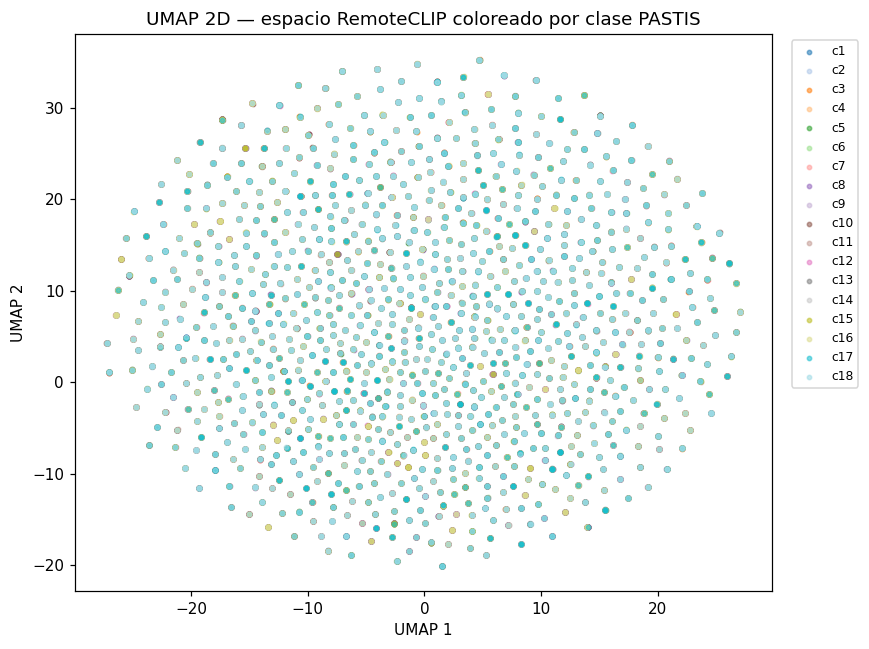

> UMAP FarSLIP omitido (merged < 50 parcelas — sin intersección entre Italia y Francia).

In [9]:
from ml.features.selection import fit_umap_2d
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def _plot_umap_by_class(
    X: np.ndarray, y: np.ndarray, *, title: str, out_path,
):
    embedding = fit_umap_2d(X, random_state=RANDOM_STATE)
    unique_classes = sorted(set(y.tolist()))
    cmap = cm.get_cmap('tab20', max(len(unique_classes), 1))
    fig, ax = plt.subplots(figsize=(8, 6), dpi=110)
    for i, cls in enumerate(unique_classes):
        mask = y == cls
        ax.scatter(
            embedding[mask, 0], embedding[mask, 1],
            s=8, alpha=0.55, color=cmap(i), label=f'c{cls}',
        )
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title(title)
    if len(unique_classes) <= 20:
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches='tight')
    return fig

if subset_join_rc.height >= 50:
    rc_cols2 = [c for c in subset_join_rc.columns if c.startswith('remoteclip_')]
    X_rc = subset_join_rc.select(rc_cols2).to_numpy()
    y_rc = subset_join_rc['class_id'].to_numpy()
    fig_rc = _plot_umap_by_class(
        X_rc, y_rc,
        title='UMAP 2D — espacio RemoteCLIP coloreado por clase PASTIS',
        out_path=env.figures_dir / 'umap_remoteclip_by_class.png',
    )
    display(fig_rc)
    plt.close(fig_rc)
else:
    display(Markdown('> UMAP RemoteCLIP omitido (subset_join_rc < 50 parcelas).'))

if merged.height >= 50:
    fs_cols3 = [c for c in merged.columns if c.startswith('farslip_') and not c.startswith('farslip_emb_')] or [c for c in merged.columns if c.startswith('farslip_emb_')]
    X_fs = merged.select(fs_cols3).to_numpy()
    y_fs = merged['class_id'].to_numpy()
    fig_fs = _plot_umap_by_class(
        X_fs, y_fs,
        title='UMAP 2D — espacio FarSLIP coloreado por clase PASTIS',
        out_path=env.figures_dir / 'umap_farslip_by_class.png',
    )
    display(fig_fs)
    plt.close(fig_fs)
else:
    display(Markdown('> UMAP FarSLIP omitido (merged < 50 parcelas — sin intersección entre Italia y Francia).'))


## Conclusiones

**Sobre los dos extractores visuales**:

- **RemoteCLIP** (Chen et al. 2024) entrega un baseline honesto: CLIP afinado sobre 12 datasets de teledetección, sin supervisión específica de PASTIS. El F1-macro de LogReg sobre RemoteCLIP marca el piso que cualquier extractor más especializado debe superar.
- **FarSLIP** (destilación US-017 según Li et al. 2025) es el extractor entrenado en este proyecto sobre parcelas Italia. Su valor se mide contra RemoteCLIP en F1-macro y en la separabilidad visual UMAP — si los clusters quedan más definidos por clase, el espacio FarSLIP es preferible aunque el F1-macro de LogReg sea similar.

**Limitaciones honestas**:

1. FarSLIP fue destilado sobre parcelas de Italia, mientras que el subset PASTIS-R cubre parcelas de Francia. La intersección por `parcel_id` puede ser baja o nula. Si `merged` tiene pocas parcelas, la comparativa F1-macro directa sobre FarSLIP es ilustrativa, no concluyente. Una comparativa completa requeriría reentrenar FarSLIP sobre PASTIS (deuda futura US-025).
2. Si los pesos oficiales de RemoteCLIP no logran descargarse, se cae a `openai/clip-vit-base-patch32`; el log estructurado deja constancia de qué modelo terminó usándose.

**Sobre las preguntas oficiales**:

- **P1 (algoritmo)**: este notebook NO entrena un baseline tabular; evalúa dos *extractores* de embeddings con LogReg como cabezal lineal. La decisión de promover FarSLIP como bloque opcional del baseline tabular se delega a `05_reencuadre`.
- **P2 (importancia)**: la separabilidad visual UMAP y el F1-macro de LogReg complementan el análisis SHAP del `04` — responden a 'qué tan importante es el espacio de embedding' como bloque entero.

## Lo que sigue

- `05_reencuadre_fenologico.ipynb` evalúa FarSLIP **como bloque del baseline tabular fused** mediante ablación (`with_farslip`, `farslip_only`).
- `Avance3.Equipo17.ipynb` consolida la decisión de promover, diferir o descartar FarSLIP.